In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
import numpy as np
import rasterio
from matplotlib.colors import ListedColormap
from rasterio.features import geometry_mask
from zipfile import ZipFile
import io
from rasterio.mask import mask
from sklearn.metrics import explained_variance_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Part 1

### Q1: How many counties are in Wisconsin?

In [42]:
gdf = gpd.read_file('counties.geojson')
gdf["NAME"].nunique()

72

In [43]:
gdf.head()

,NAME,POP100,geometry
0,Racine County,195408,"POLYGON ((-88.07073 42.66976, -88.06897 42.669..."
1,Clark County,34690,"POLYGON ((-90.55875 44.42221, -90.53398 44.422..."
2,Wood County,74749,"POLYGON ((-89.72464 44.33712, -89.7246 44.3384..."
3,Rusk County,14755,"POLYGON ((-90.92517 45.37935, -90.92515 45.379..."
4,Ozaukee County,86395,"POLYGON ((-87.89269 43.19202, -87.89265 43.192..."


### Q2: What is the population of each county in WI?

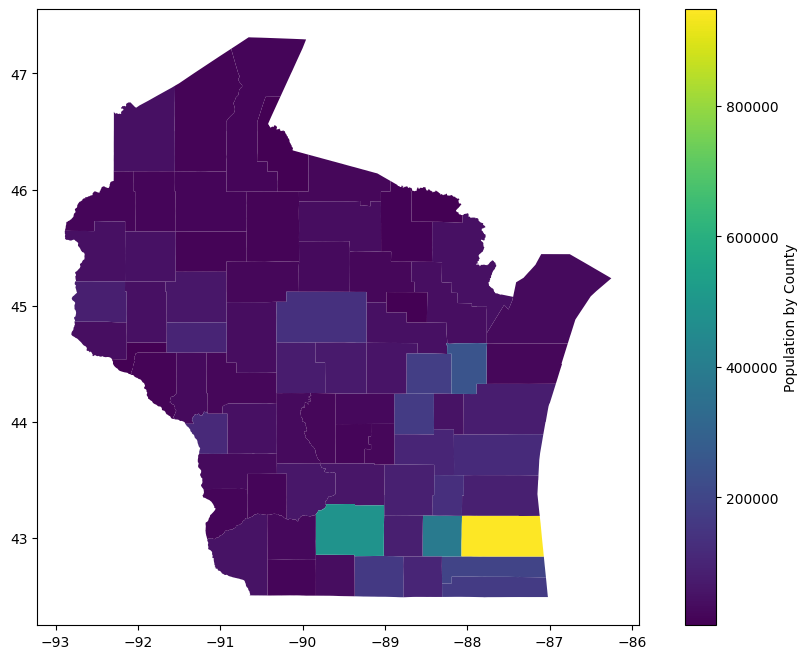

In [44]:
#Q2
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column='POP100', 
          cmap='viridis', 
          legend=True, 
          legend_kwds={'label': "Population by County"},
          ax=ax)
# plt.savefig("img/population_WI")
plt.show()

### Q3: What are the counties in the test dataset?

In [45]:
#Q3
conn = sqlite3.connect("counties_tracts.db")

area_data = pd.read_sql("""
    SELECT NAME, AREALAND
    FROM counties
""", conn)

conn.close()

gdf = gdf.merge(area_data, on="NAME", how="left")

train, test = train_test_split(gdf, test_size=0.25, random_state=320)

test_counties = test["NAME"].tolist()

test_counties

['Kewaunee County',
 'Calumet County',
 'Adams County',
 'Eau Claire County',
 'Milwaukee County',
 'Ashland County',
 'Wood County',
 'Dodge County',
 'Sauk County',
 'Clark County',
 'Pepin County',
 'Taylor County',
 'Iron County',
 'Outagamie County',
 'Florence County',
 'Oneida County',
 'Pierce County',
 'Grant County']

### Q4: How much variance in the POP100 can a LinearRegression model explain based only on AREALAND?

In [46]:
#Q4
X_train = train[['AREALAND']]
y_train = train['POP100']
X_test = test[['AREALAND']]
y_test = test['POP100']

model = LinearRegression()
model.fit(X_train, y_train)

r2score = model.score(X_test, y_test)

r2score

0.022002661530554857

### Q5: What is the predicted population of a county with 300 square miles of area, according to the model?

In [47]:
#Q5
area_sq_miles = 300
area_sq_meters = area_sq_miles * 2_590_000

input_data = pd.DataFrame({'AREALAND': [area_sq_meters]})

predicted_population = model.predict(input_data)[0]

float(predicted_population)


89016.40396725974

## Part 2: Predicting Population using Housing Units

#### Splitting my updated GeoDataFrame into a train and test set

In [48]:
conn = sqlite3.connect('counties_tracts.db')

query = """
SELECT counties.NAME, SUM(tracts.HU100) AS total_HU100
FROM counties
INNER JOIN tracts ON counties.COUNTY == tracts.COUNTY
GROUP BY counties.NAME
"""

housing_units = pd.read_sql(query, conn)

conn.close()

gdf = gdf.merge(housing_units, how='left', left_on='NAME', right_on='NAME')


X = gdf[['AREALAND', 'total_HU100']]
y = gdf['POP100']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=320)

print(X_test)

      AREALAND  total_HU100
58   886954383         9304
61   824263566        19695
65  1672317888        17436
25  1652149982        42151
15   625435295       418053
53  2706460371         9656
2   2054044751        34088
12  2268044444        37005
26  2152060188        29708
1   3133378070        15076
9    600894491         3579
22  2525357276        10582
28  1963751254         5999
29  1651265932        73149
21  1264237736         4780
32  2883704998        30125
41  1486279430        16132
14  2970401211        21581


### Q6: What are the counties in the test dataset?

In [49]:
#Q6
test_indices = X_test.index

counties_in_test = gdf.loc[test_indices, 'NAME'].tolist()

counties_in_test

['Kewaunee County',
 'Calumet County',
 'Adams County',
 'Eau Claire County',
 'Milwaukee County',
 'Ashland County',
 'Wood County',
 'Dodge County',
 'Sauk County',
 'Clark County',
 'Pepin County',
 'Taylor County',
 'Iron County',
 'Outagamie County',
 'Florence County',
 'Oneida County',
 'Pierce County',
 'Grant County']

### Q7: What are the HU100 values for the counties in the test dataset?

In [50]:
#Q7
test_indices = X_test.index

hu100_values = gdf.loc[test_indices, ['NAME', 'total_HU100']]

hu100_dict = hu100_values.set_index('NAME')['total_HU100'].to_dict()

hu100_dict

{'Kewaunee County': 9304,
 'Calumet County': 19695,
 'Adams County': 17436,
 'Eau Claire County': 42151,
 'Milwaukee County': 418053,
 'Ashland County': 9656,
 'Wood County': 34088,
 'Dodge County': 37005,
 'Sauk County': 29708,
 'Clark County': 15076,
 'Pepin County': 3579,
 'Taylor County': 10582,
 'Iron County': 5999,
 'Outagamie County': 73149,
 'Florence County': 4780,
 'Oneida County': 30125,
 'Pierce County': 16132,
 'Grant County': 21581}

### Q8: How much variance in the POP100 can a LinearRegression model explain based only on HU100?

In [51]:
#Q8
X_train_hu = X_train[['total_HU100']]
y_train = y_train

model = LinearRegression()

scores = cross_val_score(model, X_train_hu, y_train, cv=5, scoring='r2')

average_score = scores.mean()
float(average_score)

0.9652534544116035

### Q9: What is the standard deviation of the cross validation scores from Q8?

In [52]:
#Q9
std_dev = np.sqrt(((scores - average_score) ** 2).mean())

float(std_dev)

0.03704265206670458

### Q10: What is the formula relating POP100 and HU100?

In [53]:
#Q10
model.fit(X_train_hu, y_train)

coefficient = round(model.coef_[0], 2)
intercept = round(model.intercept_, 2)

formula = f"POP100 = {coefficient}*HU100 + {intercept}"

formula

'POP100 = 2.39*HU100 + -7910.46'

### Q11: What is the r-squared score of your fitted model (from Q10)?

In [54]:
#Q11
y_pred = model.predict(X_test[['total_HU100']])

r_squared = r2_score(y_test, y_pred)

r_squared

0.9958323488562859

### Q12: What is the relationship between HU100 and POP100, visually?

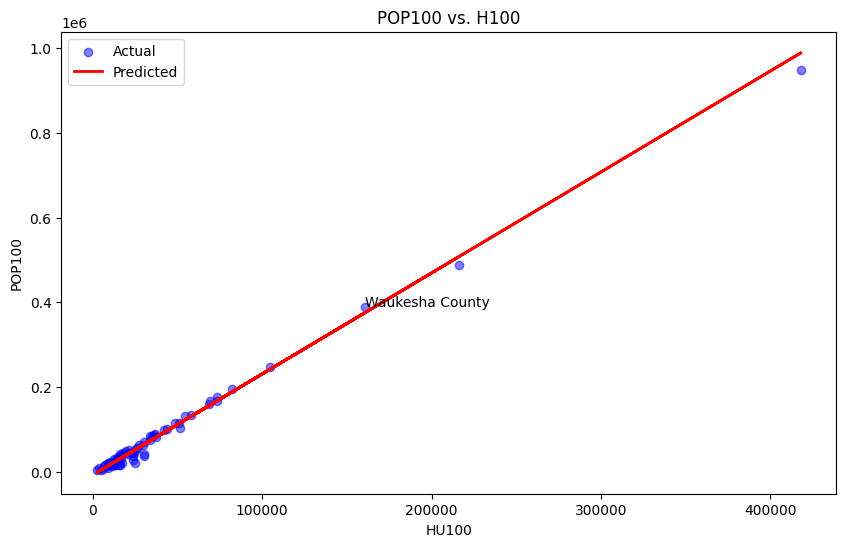

In [55]:
#Q12

X_full = pd.concat([X_train[['total_HU100']], X_test[['total_HU100']]])
y_full = pd.concat([y_train, y_test])

y_full_pred = model.predict(X_full[['total_HU100']])

plt.figure(figsize=(10, 6))
plt.scatter(X_full['total_HU100'], y_full, label='Actual', color='blue', alpha=0.5)
plt.plot(X_full['total_HU100'], y_full_pred, label='Predicted', color='red', linewidth=2)

waukesha_index = gdf[gdf['NAME'] == 'Waukesha County'].index[0]
plt.text(X_full.iloc[waukesha_index]['total_HU100'], y_full.iloc[waukesha_index], 'Waukesha County', color='black')

plt.xlabel('HU100')
plt.ylabel('POP100')
plt.title('POP100 vs. H100')
plt.legend()

# plt.savefig("img/bestfitline_POP100vsH100")
plt.show()


## Part 3: Land Use Features

### Q13: How many numbers in matrix A are between 1 and 4 (inclusive)?

In [56]:
#Q13
A = np.array([
    [0, 0, 5, 8, 4],
    [1, 2, 4, 0, 3],
    [2, 4, 0, 9, 2],
    [3, 5, 2, 1, 1],
    [0, 5, 0, 1, 0]
])

count = np.sum((A >= 1) & (A <= 4))
int(count)

13

In [57]:
c = np.zeros((256,3))
c[0] = [0.00000000000, 0.00000000000, 0.00000000000]
c[11] = [0.27843137255, 0.41960784314, 0.62745098039]
c[12] = [0.81960784314, 0.86666666667, 0.97647058824]
c[21] = [0.86666666667, 0.78823529412, 0.78823529412]
c[22] = [0.84705882353, 0.57647058824, 0.50980392157]
c[23] = [0.92941176471, 0.00000000000, 0.00000000000]
c[24] = [0.66666666667, 0.00000000000, 0.00000000000]
c[31] = [0.69803921569, 0.67843137255, 0.63921568628]
c[41] = [0.40784313726, 0.66666666667, 0.38823529412]
c[42] = [0.10980392157, 0.38823529412, 0.18823529412]
c[43] = [0.70980392157, 0.78823529412, 0.55686274510]
c[51] = [0.64705882353, 0.54901960784, 0.18823529412]
c[52] = [0.80000000000, 0.72941176471, 0.48627450980]
c[71] = [0.88627450980, 0.88627450980, 0.75686274510]
c[72] = [0.78823529412, 0.78823529412, 0.46666666667]
c[73] = [0.60000000000, 0.75686274510, 0.27843137255]
c[74] = [0.46666666667, 0.67843137255, 0.57647058824]
c[81] = [0.85882352941, 0.84705882353, 0.23921568628]
c[82] = [0.66666666667, 0.43921568628, 0.15686274510]
c[90] = [0.72941176471, 0.84705882353, 0.91764705882]
c[95] = [0.43921568628, 0.63921568628, 0.72941176471]
custom_cmap = ListedColormap(c)

### Q14: How does Dane County look?

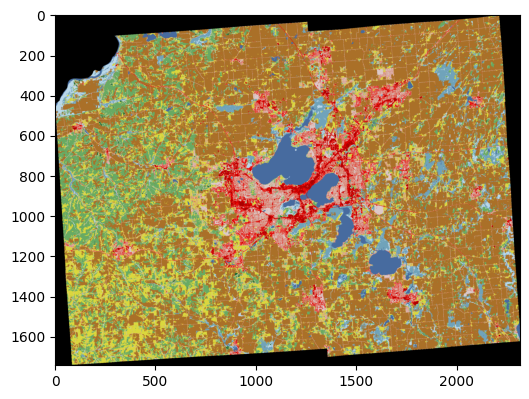

In [58]:
#Q14
dane_county = gdf[gdf['NAME'] == 'Dane County']

f = rasterio.open("zip://./land.zip!/wi.tif", "r")
fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(out_image, cmap=custom_cmap, vmin=0, vmax=255)

matrix, _ = mask(f, dane_county.to_crs(f.crs)["geometry"], crop=True)
matrix = matrix[0]

# plt.savefig("img/DaneCounty_colormap")

ax.imshow(matrix, cmap=custom_cmap, vmin=0, vmax=255)

In [59]:
land_use = {"open_water": 11,
            "ice_snow": 12,
            "developed_open": 21,
            "developed_low": 22,
            "developed_med": 23,
            "developed_high": 24,
            "barren": 31,
            "deciduous": 41,
            "evergreen": 42,
            "mixed_forest": 43,
            "dwarf_scrub": 51,
            "shrub_scrub": 52,
            "grassland": 71,
            "sedge": 72,
            "lichens": 73,
            "moss": 74,
            "pasture": 81,
            "crops": 82,
            "woody_wetlands": 90,
            "herbacious_wetlands": 95}

### Q15: What portion of Dane County is "Crops"?

In [60]:
#Q15
crops_code = land_use["crops"]

valid_cells = matrix[matrix != 0]

total_valid_cells = valid_cells.size

crops_cells = np.sum(valid_cells == crops_code)

crops_percentage = (crops_cells / total_valid_cells)

float(crops_percentage)

0.46705544316564085

### Q16: What is the Relationship Between POP100 and ________________?

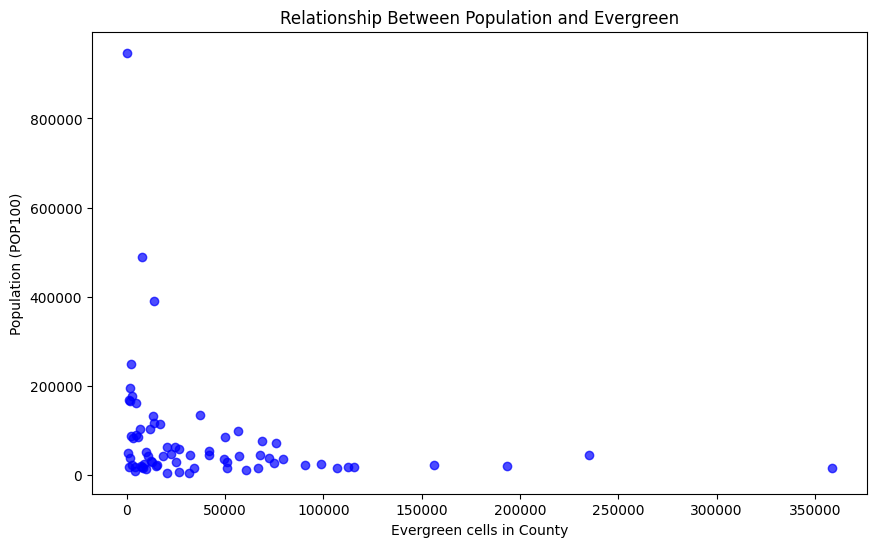

In [61]:
#Q16
counties_list = list(gdf["NAME"])
f = rasterio.open("zip://./land.zip!/wi.tif", "r")

crops_cells_list = []

for county in counties_list:
    matrix, _ = mask(f, gdf[gdf['NAME'] == county].to_crs(f.crs)["geometry"], crop=True)
    matrix = matrix[0]
    pop100 = gdf[gdf["NAME"]== county]["POP100"]
    crops_code = land_use["evergreen"]

    valid_cells = matrix[matrix != 0]

    total_valid_cells = valid_cells.size

    crops_cells = np.sum(valid_cells == crops_code)
    crops_cells_list.append(crops_cells)

    
gdf["EVERGREEN"] = crops_cells_list


plt.figure(figsize=(10, 6))
plt.scatter(gdf["EVERGREEN"], gdf["POP100"], color="blue", alpha=0.7)
plt.title("Relationship Between Population and Evergreen")
plt.ylabel("Population (POP100)")
plt.xlabel("Evergreen cells in County")

# plt.savefig("img/scatterplot")
plt.show()

# Part 1: Feature Analysis

In [62]:
land_use_raster = rasterio.open("zip://./land.zip!/wi.tif")

def get_land_use(name, src_df):
    locale_df = src_df.loc[[name]]
    # print(locale_df)
    matrix, _ = mask(land_use_raster, locale_df.to_crs(land_use_raster.crs)["geometry"], crop=True)
    matrix = matrix[0]

    for land_type, code in land_use.items():
        n_used = (matrix == code).sum()
        src_df.at[name, land_type] = n_used

gdf.index.to_series().apply(get_land_use, args=(gdf,))

0     None
1     None
2     None
3     None
4     None
      ... 
67    None
68    None
69    None
70    None
71    None
Length: 72, dtype: object

In [63]:
tracts = gpd.read_file("tracts.shp")
tracts.set_index("GEOID")
tracts.index.to_series().apply(get_land_use, args=(tracts,))
tracts.head(3)

,GEOID,POP100,geometry,open_water,ice_snow,developed_open,developed_low,developed_med,developed_high,barren,...,dwarf_scrub,shrub_scrub,grassland,sedge,lichens,moss,pasture,crops,woody_wetlands,herbacious_wetlands
0,55001950204,1646,"POLYGON ((-90.02638 44.08721, -90.02627 44.089...",55465.0,0.0,12351.0,5402.0,833.0,104.0,175.0,...,0.0,18518.0,33652.0,0.0,0.0,0.0,3136.0,73433.0,84766.0,20975.0
1,55009940002,4698,"POLYGON ((-88.15018 44.51202, -88.1501 44.5139...",57.0,0.0,1456.0,2104.0,1211.0,243.0,229.0,...,0.0,23.0,38.0,0.0,0.0,0.0,770.0,1503.0,2317.0,123.0
2,55061990000,0,"POLYGON ((-87.53727 44.33179, -87.53547 44.334...",2107187.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
train, test = train_test_split(tracts, random_state=320, test_size=0.20)

In [65]:
features = [col for col in land_use.keys()]
lr = LinearRegression()
lr.fit(train[features], train["POP100"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Q17: What features does your model rely on most?

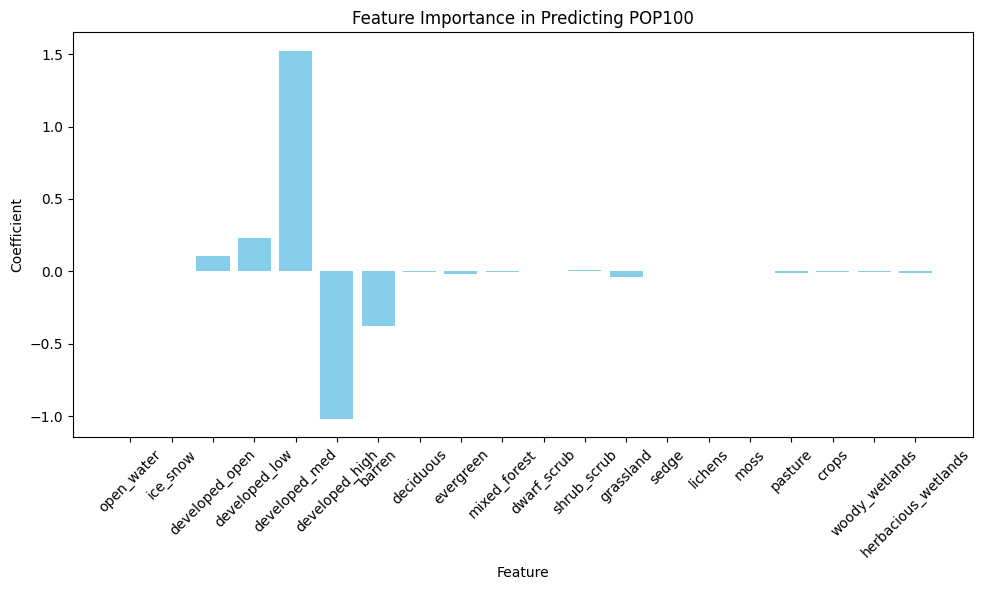

In [66]:
#Q17
coefficients = lr.coef_

plt.figure(figsize=(10, 6))
plt.bar(features, coefficients, color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Feature Importance in Predicting POP100')
plt.xticks(rotation=45)
plt.tight_layout()

# plt.savefig("img/barplot_featureimportance")
plt.show()


# Part 2: Model Creation and Analysis

### Q18: What is the mean and variance of the cross validation scores from both of your models?

In [67]:
#Q18
model1 = LinearRegression()

model2 = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

cv_scores_model1 = cross_val_score(model1, train[features], train["POP100"], cv=5)
cv_scores_model2 = cross_val_score(model2, train[features], train["POP100"], cv=5)

results = {
    'model1-avg': float(np.mean(cv_scores_model1)),
    'model1-std': float(np.std(cv_scores_model1)),
    'model2-avg': float(np.mean(cv_scores_model2)),
    'model2-std': float(np.std(cv_scores_model2))
}

results

{'model1-avg': 0.5154824074886635,
 'model1-std': 0.023980540400256,
 'model2-avg': 0.5154824074886634,
 'model2-std': 0.023980540400255615}

### Q19: How does your recommended model score against the test dataset?

In [68]:
#Q19
recommended_model = model2 #safer option
recommended_model.fit(train[features], train["POP100"])

test_predictions = recommended_model.predict(test[features])
explained_variance = explained_variance_score(test["POP100"], test_predictions)
explained_variance

0.3890923601919327